In [11]:
## DATA MANIPULATION
# FILTERING, SELECTING, GROUPING, AGGREGATION, SORTING
# NEW COLUMN CREATION, CHANGE DATA SHAPE

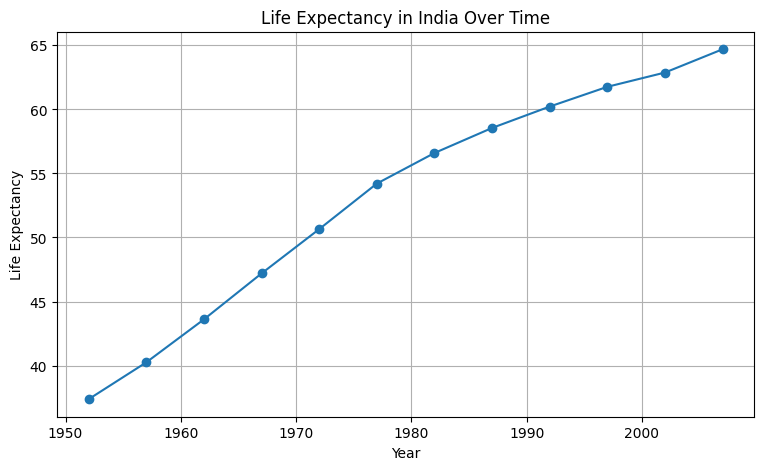

In [1]:
## 1. Filter rows, then plot one country over time
# Row filtering by selecting one country before plotting a time series.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

country = df[df["country"] == "India"]

plt.figure(figsize=(9, 5))
plt.plot(country["year"], country["lifeExp"], marker="o")

plt.title("Life Expectancy in India Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.grid(True)

plt.show()

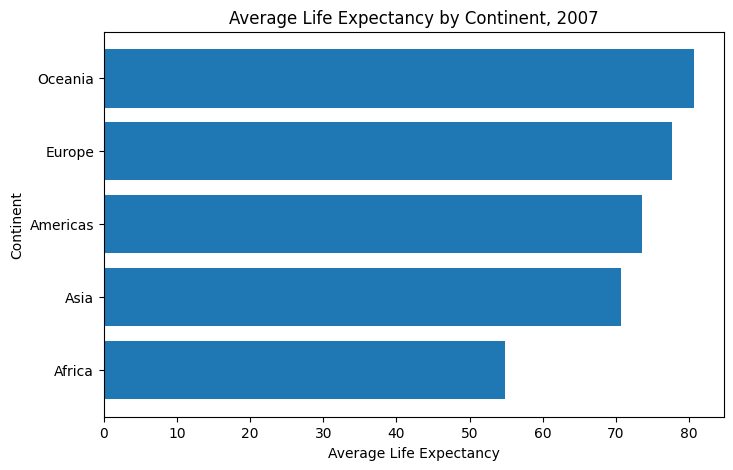

In [2]:
## 2. Group by continent and calculate averages
# groupby(), aggregation, and sorting before making a bar chart.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

data_2007 = df[df["year"] == 2007]

avg_life = (
    data_2007
    .groupby("continent")["lifeExp"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.barh(avg_life.index, avg_life.values)

plt.title("Average Life Expectancy by Continent, 2007")
plt.xlabel("Average Life Expectancy")
plt.ylabel("Continent")

plt.show()

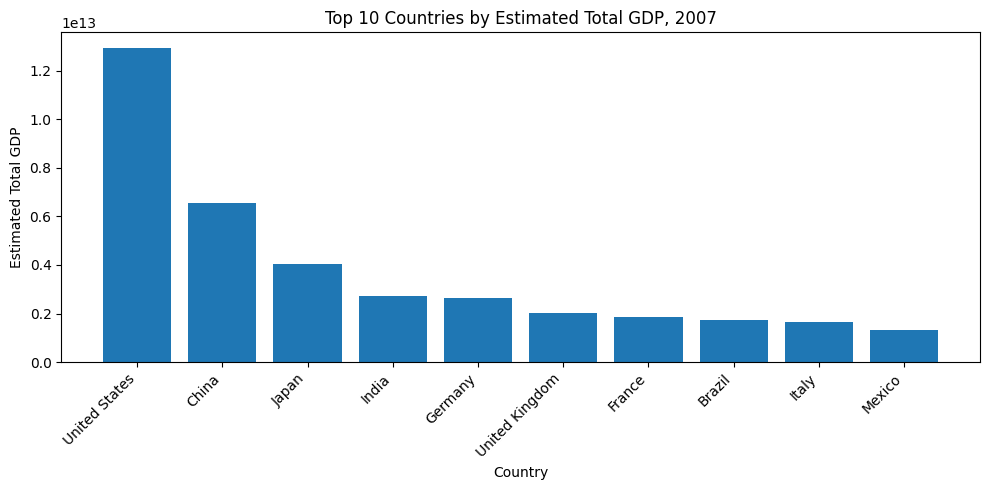

In [3]:
## 3. Create a new calculated column
# feature engineering by creating a new column from existing columns.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

data_2007 = df[df["year"] == 2007].copy()

data_2007["total_gdp"] = data_2007["pop"] * data_2007["gdpPercap"]

top_10 = (
    data_2007
    .sort_values("total_gdp", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_10["country"], top_10["total_gdp"])

plt.title("Top 10 Countries by Estimated Total GDP, 2007")
plt.xlabel("Country")
plt.ylabel("Estimated Total GDP")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

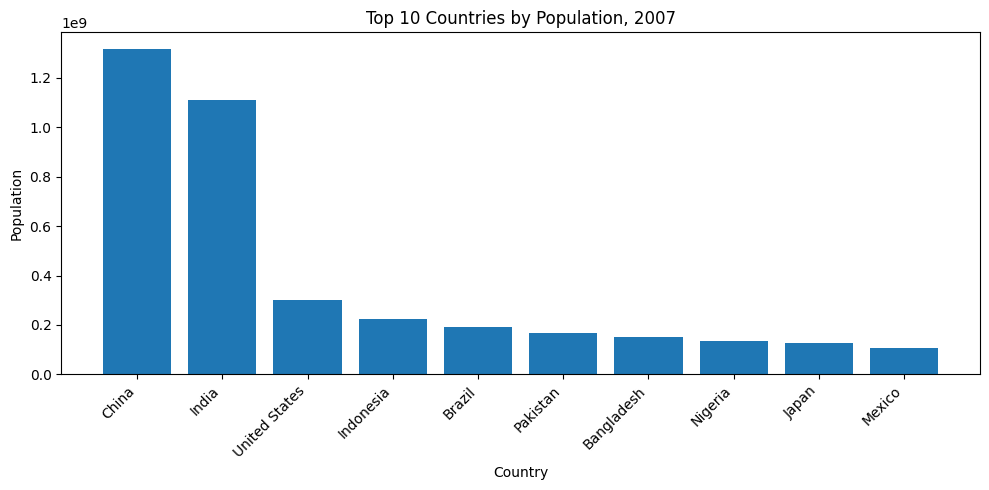

In [4]:
## 4. Sort and select the top N rows
# sorting and selecting the largest values before plotting.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

data_2007 = df[df["year"] == 2007]

top_population = (
    data_2007
    .sort_values("pop", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_population["country"], top_population["pop"])

plt.title("Top 10 Countries by Population, 2007")
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

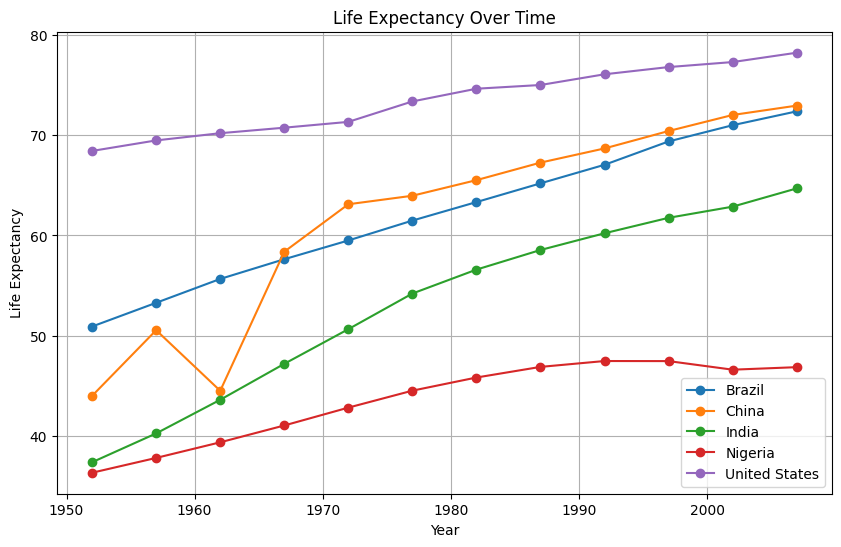

In [5]:
## 5. Pivot data from long format to wide format
# pivot() turns long data into a wide table that is easier to plot as multiple lines.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

countries = ["United States", "China", "India", "Brazil", "Nigeria"]

subset = df[df["country"].isin(countries)]

wide = subset.pivot(
    index="year",
    columns="country",
    values="lifeExp"
)

plt.figure(figsize=(10, 6))

for country in wide.columns:
    plt.plot(wide.index, wide[country], marker="o", label=country)

plt.title("Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
## DATA MANIPULATION
# CONVERT NUMERIC DATA TO CATEGORIES, DATE CONVERSION,
# AGGREGATE DAILY DATA INTO MONTHLY DATA, COUNT IN GROUPS,
# ROLLING AVERAGES TO SMOOTH NOISY DATA,
# DATA RESAMPLING, FILLING MISSING DATA,
# CONVERT CATEGORIES TO NUMERIC

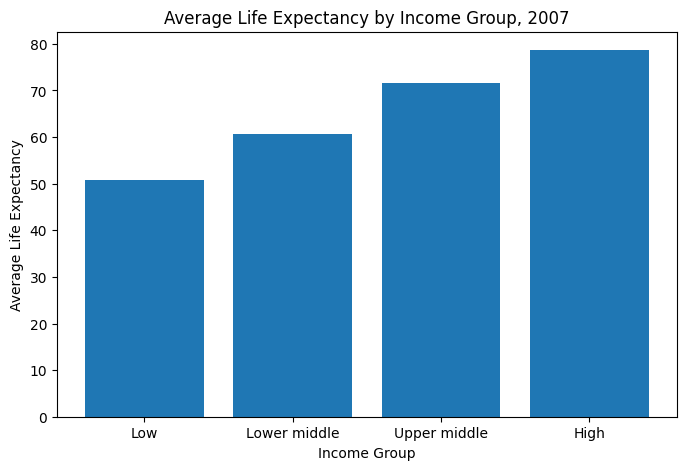

In [6]:
## 6. Bin numeric values into categories
# pd.cut() turns continuous numeric data into categories.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

data_2007 = df[df["year"] == 2007].copy()

data_2007["income_group"] = pd.cut(
    data_2007["gdpPercap"],
    bins=[0, 1000, 5000, 15000, 50000],
    labels=["Low", "Lower middle", "Upper middle", "High"]
)

avg_life = (
    data_2007
    .groupby("income_group")["lifeExp"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.bar(avg_life.index.astype(str), avg_life.values)

plt.title("Average Life Expectancy by Income Group, 2007")
plt.xlabel("Income Group")
plt.ylabel("Average Life Expectancy")

plt.show()

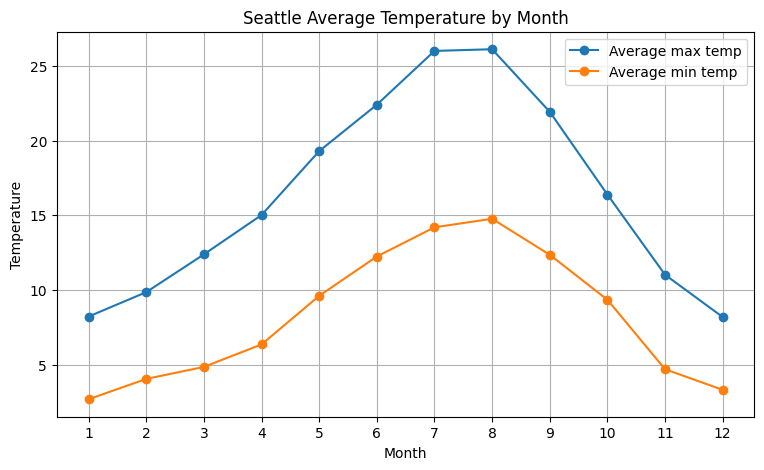

In [7]:
## 7. Date parsing and monthly aggregation
# date conversion, extracting month values, 
# and aggregating daily data into monthly summaries.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vega.github.io/vega-lite/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

monthly = (
    df
    .groupby("month")[["temp_max", "temp_min"]]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(monthly.index, monthly["temp_max"], marker="o", label="Average max temp")
plt.plot(monthly.index, monthly["temp_min"], marker="o", label="Average min temp")

plt.title("Seattle Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()

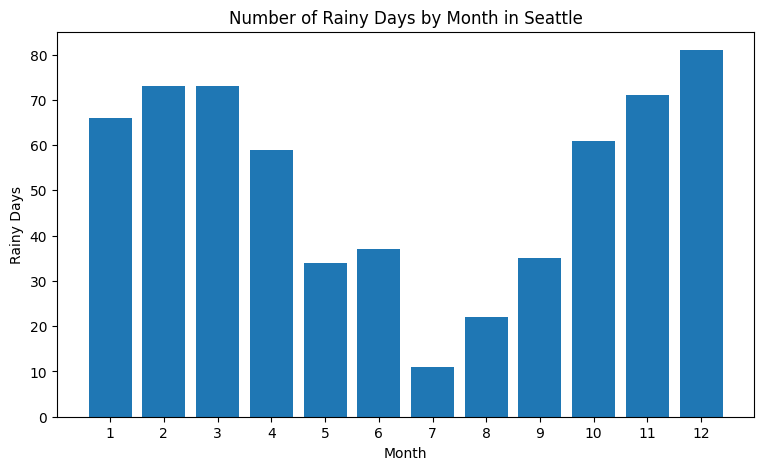

In [8]:
## 8. Count categories after filtering
# boolean filtering followed by counting rows within groups.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vega.github.io/vega-lite/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

rainy_days = (
    df[df["precipitation"] > 0]
    .groupby("month")
    .size()
)

plt.figure(figsize=(9, 5))
plt.bar(rainy_days.index, rainy_days.values)

plt.title("Number of Rainy Days by Month in Seattle")
plt.xlabel("Month")
plt.ylabel("Rainy Days")
plt.xticks(range(1, 13))

plt.show()

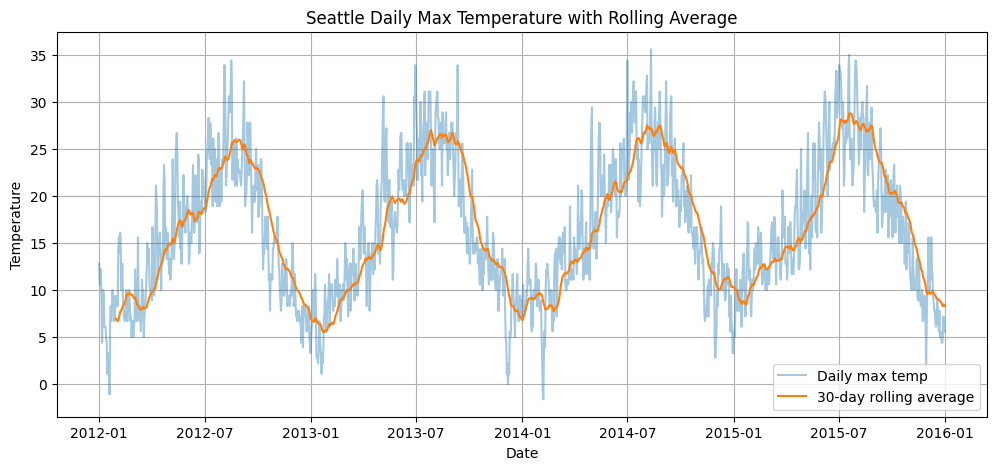

In [9]:
## 9. Rolling average for smoothing a time series
# rolling averages, which are useful for smoothing noisy time-series data.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vega.github.io/vega-lite/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df["temp_max_30_day_avg"] = df["temp_max"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["temp_max"], alpha=0.4, label="Daily max temp")
plt.plot(df["date"], df["temp_max_30_day_avg"], label="30-day rolling average")

plt.title("Seattle Daily Max Temperature with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)

plt.show()

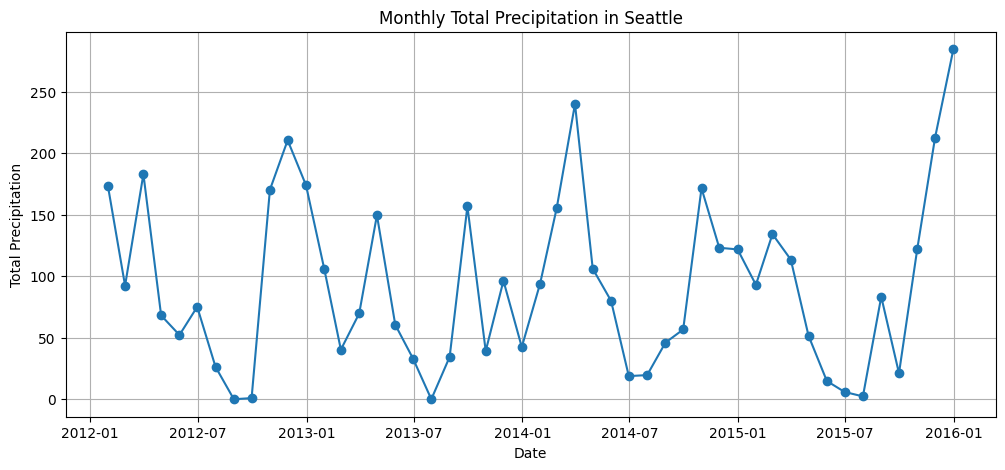

In [10]:
## 10. Resample daily data into monthly data
# time-series resampling by converting daily precipitation into monthly totals.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vega.github.io/vega-lite/data/seattle-weather.csv"

df = pd.read_csv(url)

df["date"] = pd.to_datetime(df["date"])

monthly_precip = (
    df
    .set_index("date")["precipitation"]
    .resample("ME")
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_precip.index, monthly_precip.values, marker="o")

plt.title("Monthly Total Precipitation in Seattle")
plt.xlabel("Date")
plt.ylabel("Total Precipitation")
plt.grid(True)

plt.show()

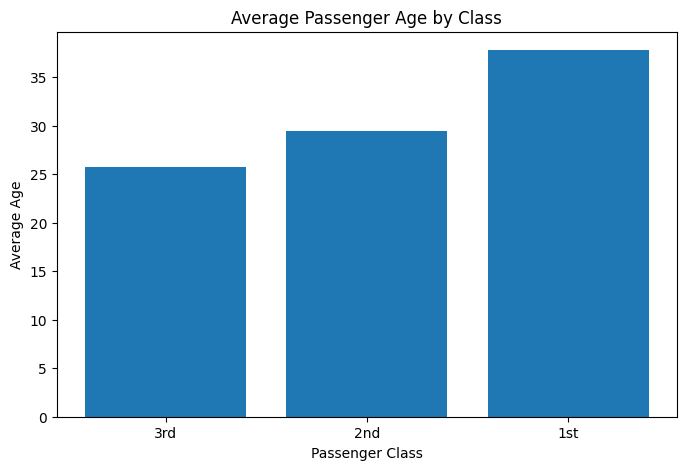

In [1]:
## 11. Handle missing values before plotting
# filling missing values before calculating group summaries.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"

df = pd.read_csv(url)

df["age"] = df["age"].fillna(df["age"].median())

age_by_class = (
    df
    .groupby("passengerClass")["age"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.bar(age_by_class.index, age_by_class.values)

plt.title("Average Passenger Age by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Age")

plt.show()

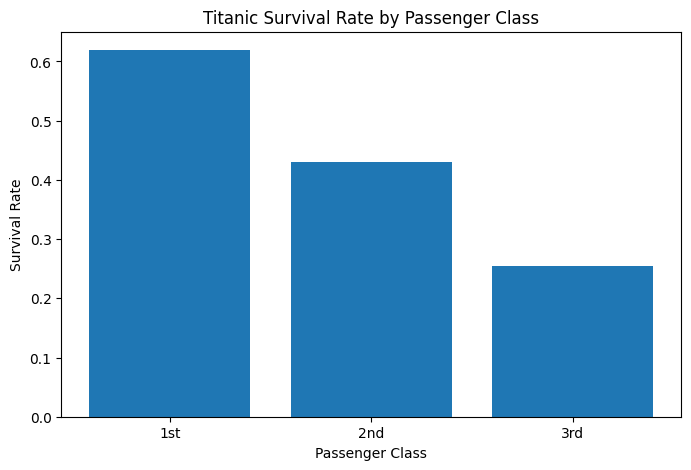

In [2]:
## 12. Convert text categories into numeric values
# mapping text values into numbers so survival rates can be calculated.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"

df = pd.read_csv(url)

df["survived_numeric"] = df["survived"].map({
    "yes": 1,
    "no": 0
})

survival_rate = (
    df
    .groupby("passengerClass")["survived_numeric"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.bar(survival_rate.index, survival_rate.values)

plt.title("Titanic Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

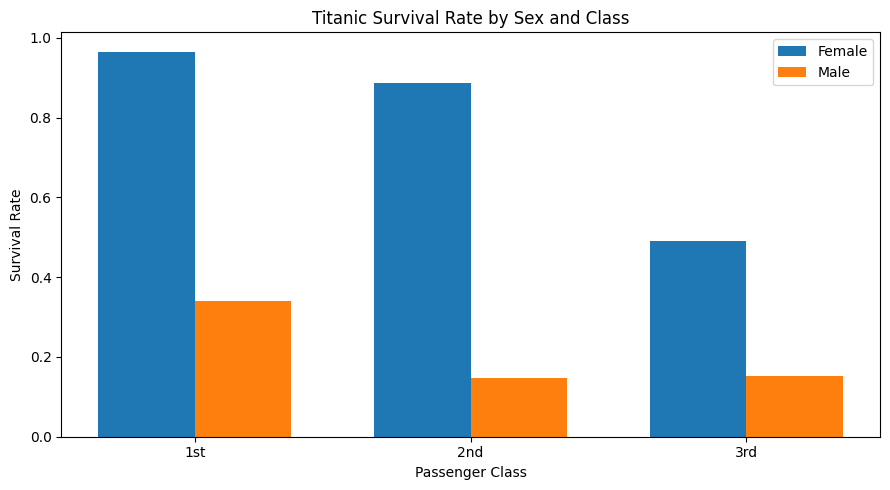

In [3]:
## 13. Group by two columns and reshape with unstack()
# multi-column grouping and reshaping grouped results into a plottable table.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"

df = pd.read_csv(url)

df["survived_numeric"] = df["survived"].map({
    "yes": 1,
    "no": 0
})

summary = (
    df
    .groupby(["passengerClass", "sex"])["survived_numeric"]
    .mean()
    .unstack()
)

x = np.arange(len(summary.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width / 2, summary["female"], width, label="Female")
ax.bar(x + width / 2, summary["male"], width, label="Male")

ax.set_title("Titanic Survival Rate by Sex and Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.legend()

plt.tight_layout()
plt.show()

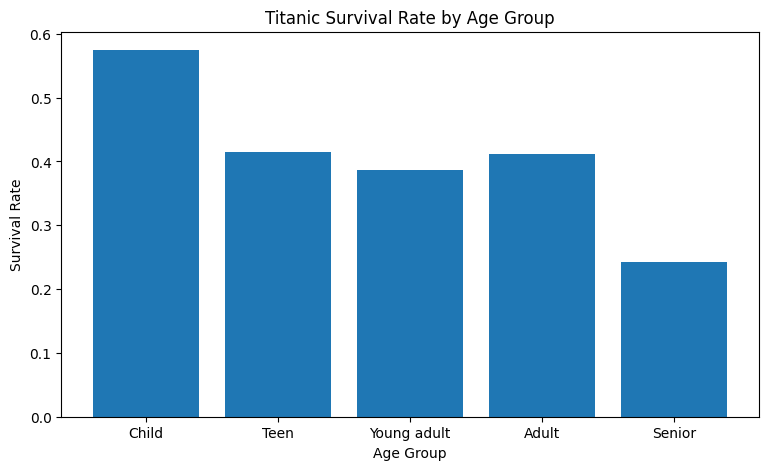

In [4]:
## 14. Create age groups and compare survival
# binning ages into groups before comparing survival rates.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv"

df = pd.read_csv(url)

df = df.dropna(subset=["age"]).copy()

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young adult", "Adult", "Senior"]
)

df["survived_numeric"] = df["survived"].map({
    "yes": 1,
    "no": 0
})

survival_by_age = (
    df
    .groupby("age_group")["survived_numeric"]
    .mean()
)

plt.figure(figsize=(9, 5))
plt.bar(survival_by_age.index.astype(str), survival_by_age.values)

plt.title("Titanic Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

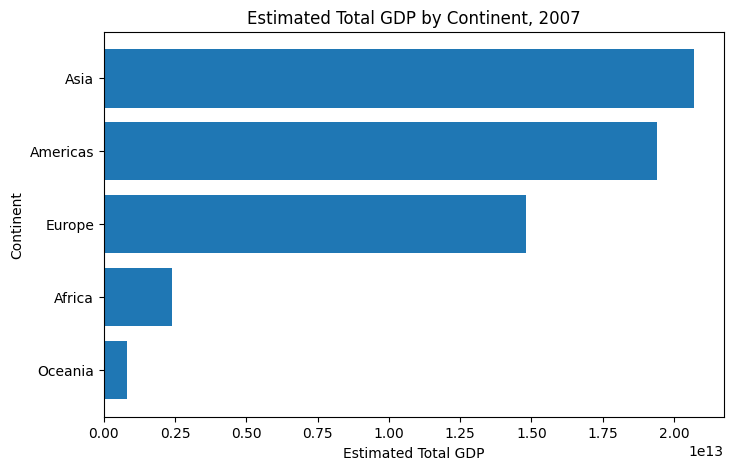

In [5]:
## 15. Combine multiple transformations with method chaining
# method chaining by filtering, creating a column, grouping, 
# summing, and sorting in one readable pipeline.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

result = (
    df[df["year"] == 2007]
    .assign(total_gdp=lambda x: x["pop"] * x["gdpPercap"])
    .groupby("continent")["total_gdp"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.barh(result.index, result.values)

plt.title("Estimated Total GDP by Continent, 2007")
plt.xlabel("Estimated Total GDP")
plt.ylabel("Continent")

plt.show()

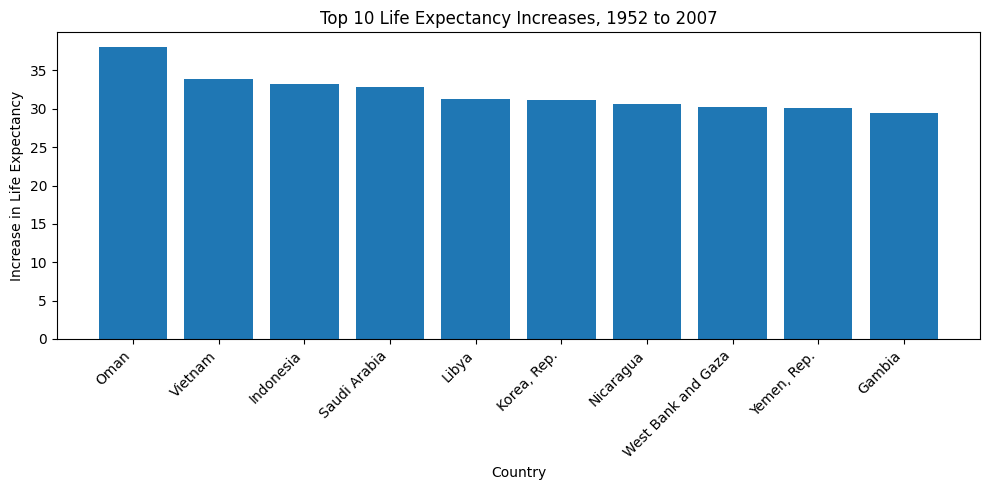

In [6]:
## 16. Compare change between first and last year
# merging two filtered DataFrames to calculate change over time.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df = pd.read_csv(url)

first_year = df["year"].min()
last_year = df["year"].max()

first = df[df["year"] == first_year][["country", "lifeExp"]]
last = df[df["year"] == last_year][["country", "lifeExp"]]

change = first.merge(
    last,
    on="country",
    suffixes=("_first", "_last")
)

change["lifeExp_change"] = change["lifeExp_last"] - change["lifeExp_first"]

top_change = (
    change
    .sort_values("lifeExp_change", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(top_change["country"], top_change["lifeExp_change"])

plt.title(f"Top 10 Life Expectancy Increases, {first_year} to {last_year}")
plt.xlabel("Country")
plt.ylabel("Increase in Life Expectancy")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()